In [ ]:
import pandas as pd
import numpy as np
import re
import time
import datetime
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.options.display.float_format = "{:,.2f}".format

user = 'postgres'
password = 'u705nyMbijVD10eeRHg7'
host = 'inmobiliariodb.clwiaum6qhir.us-east-1.rds.amazonaws.com'
port = '5432'
database = 'inmodbcore'
con_string = f'postgresql://{user}:{password}@{host}:{port}/{database}'

engine = create_engine(con_string)
conn = engine.connect()

In [ ]:
sql_query = '''
select
case
	when "TIPO" = 'Derechos y Acciones' then 'Casa'
	else "TIPO"
end as "TIPO"
, "LOCALIZACIONDELBIEN"
, "CARACTERISTICAS"
, "AREAPROPIEDAD"
, "AREACONSTRUCCION"
, "AREATERRENO"
, "AVALUOCALCULADO"
from "REMATES_INTERNO" ri
where "TIPO" not in ('Finca', 'Suite', 'Edificio')
'''


data = pd.read_sql(sql_query, conn)


In [ ]:
data.head()

,TIPO,LOCALIZACIONDELBIEN,CARACTERISTICAS,AREAPROPIEDAD,AREACONSTRUCCION,AREATERRENO,AVALUOCALCULADO
0,Casa,"PICHINCHA, QUITO",construcción principal: – desarrollado de la s...,"166,44 m2","97,00 m2",None,"35,820.40"
1,Casa,"PICHINCHA, QUITO",las características de las construcciones son ...,None,"540,45 m2. total.","405,79 m2.","22,947.94"
2,Terreno,"PICHINCHA, PEDRO VICENTE MALDONADO","terreno regular, medianero, declive negativo",328 m2,88 m2,None,"10,926.89"
3,Casa,"PICHINCHA, MEJIA",sector urbano residencial en consolidación de ...,288.00 m2,casa principal dos pisos: 144.00 m2; bodega: 8...,None,"16,345.53"
4,Terreno,"PICHINCHA, CAYAMBE",residencial rural,196,None,None,"6,464.18"


In [ ]:
# verificamos nulos
data.isnull().sum()


,0
TIPO,0
LOCALIZACIONDELBIEN,0
CARACTERISTICAS,188
AREAPROPIEDAD,602
AREACONSTRUCCION,323
AREATERRENO,6081
AVALUOCALCULADO,0


In [ ]:
# eliminamos las que no tienen características ya que esta sería la variable principal
data.dropna(subset=['CARACTERISTICAS'], inplace=True)


In [ ]:
data.isnull().sum() / data.shape[0]
# observamos que el AREATERRENO no se puede utilizar debido al % de nulos, sin embargo,
# la podemos utilizar para rellenar las otras columnas de área, pero no voy a utilizarlo


,0
TIPO,0.00
LOCALIZACIONDELBIEN,0.00
CARACTERISTICAS,0.00
AREAPROPIEDAD,0.09
AREACONSTRUCCION,0.03
AREATERRENO,0.95
AVALUOCALCULADO,0.00


In [ ]:
data['AREACONSTRUCCION'] = data.AREACONSTRUCCION.combine_first(data.AREAPROPIEDAD)
data.isnull().sum()


,0
TIPO,0
LOCALIZACIONDELBIEN,0
CARACTERISTICAS,0
AREAPROPIEDAD,532
AREACONSTRUCCION,37
AREATERRENO,5893
AVALUOCALCULADO,0


In [ ]:
# observamos que no se podría utilizar el área, ya que solo 5 casos tienen la información
data[data.AREACONSTRUCCION.isnull()].isnull().sum()
# por lo que eliminaremos estos datos


,0
TIPO,0
LOCALIZACIONDELBIEN,0
CARACTERISTICAS,0
AREAPROPIEDAD,37
AREACONSTRUCCION,37
AREATERRENO,32
AVALUOCALCULADO,0


In [ ]:
data.isnull().sum()

data.dropna(subset=['AREACONSTRUCCION'], inplace=True)


In [ ]:
# eliminamos las otras columnas que no se utilizaran
cols_delete = [
    'AREAPROPIEDAD',
    'AREATERRENO'
]
data.drop(columns=cols_delete, inplace=True)

data.isnull().sum()


,0
TIPO,0
LOCALIZACIONDELBIEN,0
CARACTERISTICAS,0
AREACONSTRUCCION,0
AVALUOCALCULADO,0


In [ ]:
# tenemos una data poblada con buena cantidad de datos
data.shape


(6191, 5)

In [ ]:
# verificamos la distribución de AVALUO
data.AVALUOCALCULADO.describe()


,AVALUOCALCULADO
count,"6,191.00"
mean,"147,202.12"
std,"2,579,746.48"
min,147.50
25%,"26,924.35"
50%,"59,221.74"
75%,"118,955.86"
max,"201,900,658.00"


<Axes: >

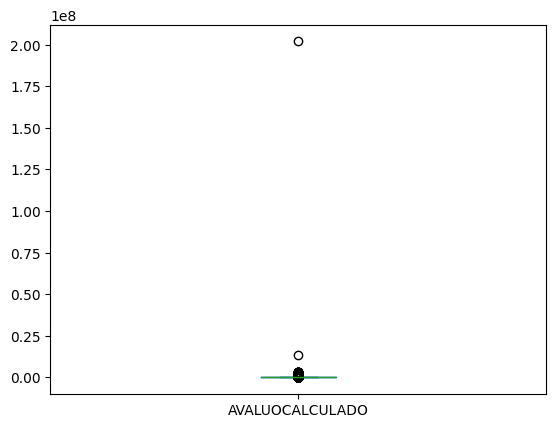

In [ ]:
data.AVALUOCALCULADO.plot(kind='box')
# vemos que hay un valor bastante extremo por lo cual, a pesar de que no se debe hacer,
# eliminaremos este valor atípico


In [ ]:
# observamos los percentiles, y, el 98% está por debajp de los 6000mil, por lo tanto podriamos eliminar
# los datos mayores a estos, sin embargo, vemos primero cuantos datos son

data.AVALUOCALCULADO.describe(percentiles=[0.8, 0.9, 0.95, 0.98, 0.99])



,AVALUOCALCULADO
count,"6,191.00"
mean,"147,202.12"
std,"2,579,746.48"
min,147.50
50%,"59,221.74"
80%,"148,384.05"
90%,"223,976.02"
95%,"344,326.97"
98%,"581,662.70"
99%,"897,010.00"


In [ ]:
data.AVALUOCALCULADO.describe(percentiles=[0.1, 0.15, 0.20, 0.25])

,AVALUOCALCULADO
count,"6,191.00"
mean,"147,202.12"
std,"2,579,746.48"
min,147.50
10%,"13,965.98"
15%,"18,069.18"
20%,"22,558.99"
25%,"26,924.35"
50%,"59,221.74"
max,"201,900,658.00"


In [ ]:
data.query('AVALUOCALCULADO >= 600000').shape


(120, 5)

In [ ]:
data.query('AVALUOCALCULADO >= 344000').shape[0] / data.shape[0]
# son 120 datos que se eliminarian, es decir el 1%


0.05007268615732515

In [ ]:
data_filtered = data.query('1000 <= AVALUOCALCULADO <= 344000').copy()
data_filtered.AVALUOCALCULADO.describe()


,AVALUOCALCULADO
count,"5,879.00"
mean,"78,158.37"
std,"69,688.18"
min,"1,040.61"
25%,"25,700.00"
50%,"55,539.00"
75%,"108,494.37"
max,"342,802.68"


<Axes: >

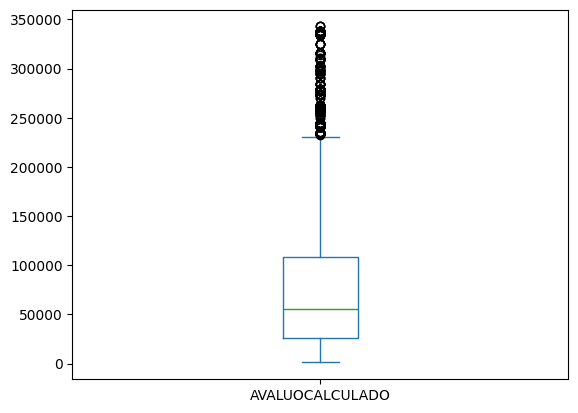

In [ ]:
data_filtered.AVALUOCALCULADO.plot(kind='box')

<Axes: ylabel='Frequency'>

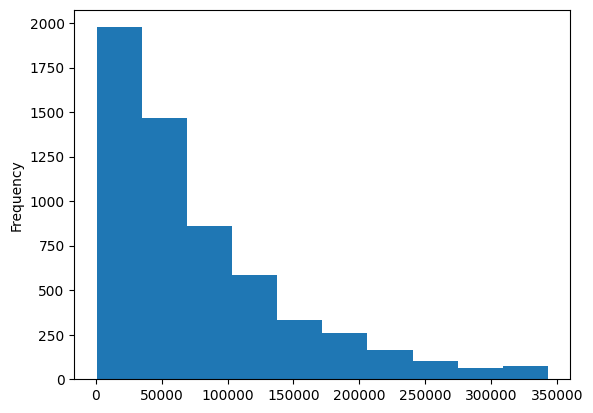

In [ ]:
data_filtered.AVALUOCALCULADO.plot(kind='hist')
# si bien se tiene datos extremos, no obstante los datos están mejores distribuidos

In [ ]:
# ahora verifiquemos que la longitud de la descripción es útil
data_filtered.CARACTERISTICAS.apply(len).describe()

,CARACTERISTICAS
count,"5,879.00"
mean,489.55
std,532.16
min,1.00
25%,94.00
50%,273.00
75%,710.00
max,"2,000.00"


In [ ]:
data_filtered[data_filtered.CARACTERISTICAS.apply(len) < 50].tail(20)
# la descripción que es menor a 50 caracteres las eliminamos, pues como se puede obervar no dice mucho


,TIPO,LOCALIZACIONDELBIEN,CARACTERISTICAS,AREACONSTRUCCION,AVALUOCALCULADO
6265,Terreno,"TUNGURAHUA, PELILEO",terreno con medias aguas,59.25m2,"18,315.50"
6269,Casa,"TUNGURAHUA, AMBATO","latitud: 1°16'01.8""s; longitud: 78°38'02.0""w",614.56 m2,"324,671.34"
6285,Casa,"COTOPAXI, LA MANA",buen estado,61.60 m2,"10,804.65"
6287,Casa,"COTOPAXI, PANGUA",buen estado,36m2,"7,875.80"
6292,Casa,"COTOPAXI, LATACUNGA",las detalladas en el informe pericial,detallados en el informe pericial,"106,135.07"
6296,Terreno,"COTOPAXI, SIGCHOS",terreno con construcciones,78.20,"3,853.45"
6306,Terreno,"COTOPAXI, PUJILI","predio vacío, sin construcciones",1207.98 m2.,"13,454.96"
6321,Terreno,"COTOPAXI, SAQUISILI",casa abandonada,478m2,"8,000.00"
6322,Terreno,"COTOPAXI, PUJILI",forma irregular y topografía pendiente,76.20 m2.,"2,387.66"
6324,Casa,"COTOPAXI, PUJILI","usada, acabados económicos",120.95 m2.,"39,958.80"


In [ ]:
data_filtered = data_filtered[data_filtered.CARACTERISTICAS.apply(len) >= 50]


<Axes: ylabel='Frequency'>

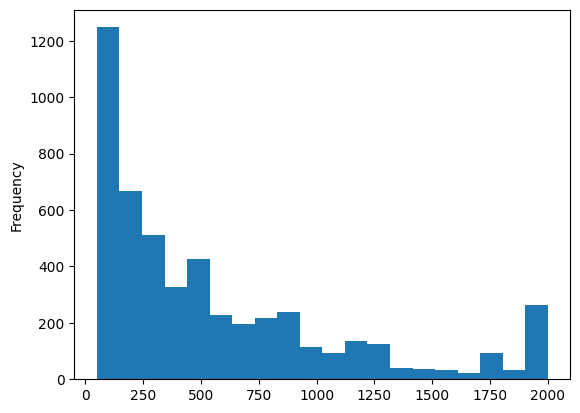

In [ ]:
data_filtered.CARACTERISTICAS.apply(len).plot(kind='hist', bins=20)

<Axes: >

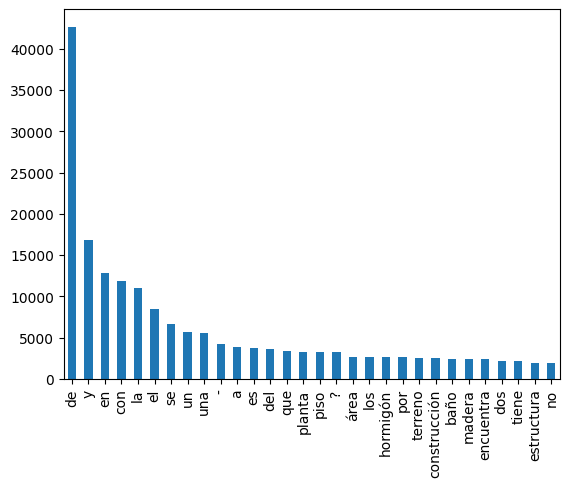

In [ ]:
res = data_filtered.CARACTERISTICAS.str.split(expand=True).stack().value_counts()
res.iloc[: 30].plot(kind='bar')

In [ ]:
# observamos que los stopwords son llas palabras más frecuentes, y luego aparencen lo de casas
# como pisos, plantas, áreas, hormigon


In [ ]:
# como queremos utilizar toda la información de texto, unimos todas las columnas con la de caracteríasticas,
# dejando de lado la de AVALUO

In [ ]:
# tipo_map = {
#     'Casa': 'Es una casa',
#     'Oficina': 'Es una oficina',
#     'Departamento': 'Es un departamento',
#     'Terreno': 'Es un terreno'
# }

# data_filtered['TIPO'] = data_filtered.TIPO.map(tipo_map)

# data_filtered['CUERPO'] = data_filtered.TIPO + \
#     ' ubicado en ' + \
#     data_filtered.LOCALIZACIONDELBIEN + \
#     ' con las siguientes características ' + \
#     data_filtered.CARACTERISTICAS + \
#     ' con una área de construcción de ' + \
#     data_filtered.AREACONSTRUCCION.astype(str)

data_filtered['CUERPO'] = data_filtered.TIPO + \
    ' ' + \
    data_filtered.LOCALIZACIONDELBIEN + \
    ' ' + \
    data_filtered.CARACTERISTICAS + \
    ' ' + \
    data_filtered.AREACONSTRUCCION.astype(str)


data_filtered['CUERPO'] = data_filtered.CUERPO.str.replace('?', '')

#! Preprocesamiento para BERT-BETO

In [ ]:
# dividimos la data en train and test
data_filtered.reset_index(drop=True, inplace=True)
train_data, test_data = train_test_split(data_filtered, train_size=0.80, random_state=888)

In [ ]:
# limpieza de texto
def treat_m2(text):
    text = re.sub(r'(m2)|(m²)', ' m²', text)
    return text

def filter_ibans(text):
    pattern = r'fr\d{2}[ ]\d{4}[ ]\d{4}[ ]\d{4}[ ]\d{4}[ ]\d{2}|fr\d{20}|fr[ ]\d{2}[ ]\d{3}[ ]\d{3}[ ]\d{3}[ ]\d{5}'
    text = re.sub(pattern, '', text)
    return text

def remove_space_between_numbers(text):
    text = re.sub(r'(\d)\s+(\d)', r'\1\2', text)
    return text


def filter_emails(text):
    pattern = r'(?:(?!.*?[.]{2})[a-zA-Z0-9](?:[a-zA-Z0-9.+!%-]{1,64}|)|\"[a-zA-Z0-9.+!% -]{1,64}\")@[a-zA-Z0-9][a-zA-Z0-9.-]+(.[a-z]{2,}|.[0-9]{1,})'
    text = re.sub(pattern, '', text)
    return text

def filter_ref(text):
    pattern = r'(\(*)(ref|réf)(\.|[ ])\d+(\)*)'
    text = re.sub(pattern, '', text)
    return text


def filter_websites(text):
    pattern = r'(http\:\/\/|https\:\/\/)?([a-z0-9][a-z0-9\-]*\.)+[a-z][a-z\-]*'
    text = re.sub(pattern, '', text)
    return text


def filter_phone_numbers(text):
    pattern = r'(?:(?:\+|00)33[\s.-]{0,3}(?:\(0\)[\s.-]{0,3})?|0)[1-9](?:(?:[\s.-]?\d{2}){4}|\d{2}(?:[\s.-]?\d{3}){2})|(\d{2}[ ]\d{2}[ ]\d{3}[ ]\d{3})'
    text = re.sub(pattern, '', text)
    return text

def clean_text(text):
    text = text.lower()
    text = text.replace(u'\xa0', u' ')
    text = treat_m2(text)
    text = filter_phone_numbers(text)
    text = filter_emails(text)
    text = filter_ibans(text)
    text = filter_ref(text)
    text = filter_websites(text)
    text = remove_space_between_numbers(text)
    return text



In [ ]:
train_data['cleaned_description'] = train_data.CUERPO.apply(clean_text)


# tokenizacion


In [ ]:
from transformers import BertModel, BertTokenizer
tokenizer = BertTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased", do_lower_case=False)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

In [ ]:
encoded_corpus = tokenizer(text=train_data.cleaned_description.tolist(),
                            add_special_tokens=True,
                            padding='max_length',
                            truncation='longest_first',
                            max_length=500,
                            return_attention_mask=True)

input_ids = encoded_corpus['input_ids']
attention_mask = encoded_corpus['attention_mask']



In [ ]:
# filtramos las características mayores a 300, dependiendo del tiempo que se demore, subiremos este número
import numpy as np

def filter_long_descriptions(tokenizer, descriptions, max_len):

    indices = []

    lengths = tokenizer(
        descriptions,
        padding=False,
        truncation=False,
        return_length=True
    )['length']

    for i in range(len(descriptions)):
        if lengths[i] <= max_len-2:
            indices.append(i)

    return indices

short_descriptions = filter_long_descriptions(
    tokenizer,
    train_data.cleaned_description.tolist(),
    500
)


Token indices sequence length is longer than the specified maximum sequence length for this model (679 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
input_ids = np.array(input_ids)[short_descriptions] #contiene las características codificadas de acuerdo a beto
attention_mask = np.array(attention_mask)[short_descriptions]
labels = train_data.AVALUOCALCULADO.to_numpy()[short_descriptions]


In [ ]:
# para evaluar el desempeño del entrenamiento, utilizamos el 10% de la data de entreno
test_size = 0.1
seed = 88
train_inputs, test_inputs, train_labels, test_labels = \
            train_test_split(
                input_ids,
                labels,
                test_size=test_size,
                random_state=seed
            )

train_masks, test_masks, _, _ = train_test_split(
    attention_mask,
    labels,
    test_size=test_size,
    random_state=seed
)


In [ ]:
# en el proceso de regresión con deep learning, se recomienda scalar la variable objetivo para
# que ayude a la estabilidad del modelo y convergencia


price_scaler = StandardScaler()
price_scaler.fit(train_labels.reshape(-1, 1))

train_labels = price_scaler.transform(train_labels.reshape(-1, 1))
test_labels = price_scaler.transform(test_labels.reshape(-1, 1))


In [ ]:
# utilizaremos el framework de pytorch
import torch
from torch.utils.data import TensorDataset, DataLoader
torch.cuda.get_device_name()

'Tesla T4'

In [ ]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
torch.cuda.get_device_properties('cuda')

_CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=15102MB, multi_processor_count=40, uuid=b6a6fd56-adaf-80f8-a5a6-4a4fb2a041d9, L2_cache_size=4MB)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
batch_size = 8

def create_dataloaders(inputs, masks, labels, batch_size):

    input_tensor = torch.tensor(inputs)
    mask_tensor = torch.tensor(masks)
    labels_tensor = torch.tensor(labels)
    dataset = TensorDataset(input_tensor, mask_tensor,
                            labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=True)
    return dataloader

train_dataloader = create_dataloaders(
    train_inputs,
    train_masks,
    train_labels,
    batch_size
)

test_dataloader = create_dataloaders(
    test_inputs,
    test_masks,
    test_labels,
    batch_size
)


In [ ]:
# definimos nuestro modelo de BETORegressor

import torch.nn as nn

# BetoModel = AutoModelForMaskedLM.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
BetoModel = BertModel.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased")


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
class BetoRegressor(nn.Module):

    def __init__(self, drop_rate=0.2, freeze_beto=False):

        super(BetoRegressor, self).__init__()
        D_in, D_out = 768, 1

        self.beto = BetoModel #.from_pretrained('bert-base-spanish-wwm-cased')
        self.regressor = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(D_in, D_out)
        )
        self.double()

    def forward(self, input_ids, attention_masks):

        outputs = self.beto(input_ids, attention_masks)
        class_label_output = outputs[1]
        outputs = self.regressor(class_label_output)
        return outputs


# instanciamos el modelo customizado
model = BetoRegressor(drop_rate=0.2)


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU.")
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")

model.to(device)


Using GPU.


BetoRegressor(
  (beto): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:
# definimos la función de pérdida
from transformers import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=5e-5,
    eps=1e-8
)


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
# definimos
from transformers import get_linear_schedule_with_warmup

epochs = 2
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

loss_function = nn.MSELoss()

print(total_steps)

900


In [ ]:
# entrenamiento del modelo
from torch.nn.utils.clip_grad import clip_grad_norm_

# def train(model,
#         optimizer,
#         scheduler,
#         loss_function,
#         epochs,
#         train_dataloader,
#         device,
#         clip_value=2):

#     for epoch in range(epochs):

#         print(epoch)
#         print("-----")
#         best_loss = 1e10
#         model.train()
#         for step, batch in enumerate(train_dataloader):
#             print(step)
#             batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)

#             model.zero_grad()

#             outputs = model(batch_inputs, batch_masks)

#             loss = loss_function(
#                 outputs.squeeze(),
#                 batch_labels.squeeze())
#             loss.backward()

#             clip_grad_norm_(model.parameters(), clip_value)
#             optimizer.step()
#             scheduler.step()

#     return model
def format_time(elapsed):

    elapsed_rounded = int(round((elapsed)))

    return str(datetime.timedelta(seconds=elapsed_rounded))




def train(model,
        optimizer,
        scheduler,
        loss_function,
        epochs,
        train_dataloader,
        device,
        clip_value=2):

    training_stats = []

    for epoch in range(epochs):

        print("")
        print('======== Epoch {:} / {:} ========'.format(epoch + 1, epochs))
        print('Training...')

        t0 = time.time()

        total_train_loss = 0

        best_loss = 1e10
        model.train()
        for step, batch in enumerate(train_dataloader):

            if step % 10 == 0 and not step == 0:
                elapsed = format_time(time.time() - t0)

                print(f' Batch {step} of {len(train_dataloader)}. Elapsed: {elapsed}.')

            # print(step)
            batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)

            model.zero_grad()

            outputs = model(batch_inputs, batch_masks)

            loss = loss_function(
                outputs.squeeze(),
                batch_labels.squeeze())

            total_train_loss += loss.item()

            loss.backward()

            clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_train_loss / len(train_dataloader)

        training_time = format_time(time.time() - t0)

        print('')
        print(f'Average training loss: {avg_train_loss}')
        print(f'Training epoch took: {training_time}')

        training_stats.append(
            {
                'epoch': epoch + 1,
                'Training Loss': avg_train_loss,
                'Training Time': training_time
            }
        )


    return model, training_stats



In [ ]:
model, training_stats = train(
    model,
    optimizer,
    scheduler,
    loss_function,
    epochs,
    train_dataloader,
    device,
    clip_value=2
)


======== Epoch 1 / 2 ========
Training...
 Batch 10 of 450. Elapsed: 0:01:45.
 Batch 20 of 450. Elapsed: 0:03:29.
 Batch 30 of 450. Elapsed: 0:05:14.
 Batch 40 of 450. Elapsed: 0:06:59.
 Batch 50 of 450. Elapsed: 0:08:43.
 Batch 60 of 450. Elapsed: 0:10:28.
 Batch 70 of 450. Elapsed: 0:12:12.
 Batch 80 of 450. Elapsed: 0:13:57.
 Batch 90 of 450. Elapsed: 0:15:41.
 Batch 100 of 450. Elapsed: 0:17:26.
 Batch 110 of 450. Elapsed: 0:19:10.
 Batch 120 of 450. Elapsed: 0:20:55.
 Batch 130 of 450. Elapsed: 0:22:39.
 Batch 140 of 450. Elapsed: 0:24:24.
 Batch 150 of 450. Elapsed: 0:26:08.
 Batch 160 of 450. Elapsed: 0:27:53.
 Batch 170 of 450. Elapsed: 0:29:37.
 Batch 180 of 450. Elapsed: 0:31:22.
 Batch 190 of 450. Elapsed: 0:33:06.
 Batch 200 of 450. Elapsed: 0:34:51.
 Batch 210 of 450. Elapsed: 0:36:36.
 Batch 220 of 450. Elapsed: 0:38:20.
 Batch 230 of 450. Elapsed: 0:40:05.
 Batch 240 of 450. Elapsed: 0:41:49.
 Batch 250 of 450. Elapsed: 0:43:34.
 Batch 260 of 450. Elapsed: 0:45:18.
 Bat

In [ ]:
# import gc
# torch.cuda.empty_cache()
# gc.collect()

In [ ]:
# funciones que debería ser utilizadas en la función train para monitorear el entrenamiento

def r2_score(outputs, labels):
    labels_mean = torch.mean(labels)
    ss_tot = torch.sum((labels - labels_mean) ** 2)
    ss_res = torch.sum((labels - outputs) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2


def evaluate(model, loss_function, test_dataloader, device):

    model.eval()
    test_loss, test_r2 = [], []

    for batch in test_dataloader:
        batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)

        with torch.no_grad():
            outputs = model(batch_inputs, batch_masks)

        loss = loss_function(outputs, batch_labels)
        test_loss.append(loss.item())
        r2 = r2_score(outputs, batch_labels)
        test_r2.append(r2.item())

    return test_loss, test_r2

# Predicciones

In [ ]:
def predict(model, dataloader, device):

    model.eval()
    output = []

    for batch in dataloader:
        batch_inputs, batch_masks, _ = tuple(b.to(device) for b in batch)
        with torch.no_grad():
            output += model(
                batch_inputs,
                batch_masks
            ).view(1,-1).tolist()[0]

    return output

In [ ]:
val_data = test_data.copy()

In [ ]:
# aplicamos el mismo preprocesamiento al data de entrenamineto
val_set = val_data[['CUERPO', 'AVALUOCALCULADO']]

val_set['cleaned_description'] = val_set.CUERPO.apply(clean_text)

encoded_val_corpus = tokenizer(
    text=val_set.cleaned_description.tolist(),
    add_special_tokens=True,
    padding='max_length',
    truncation='longest_first',
    max_length=300,
    return_attention_mask=True
)

val_input_ids = np.array(encoded_val_corpus['input_ids'])
val_attention_mask = np.array(encoded_val_corpus['attention_mask'])
val_labels = val_set.AVALUOCALCULADO.to_numpy()
val_labels = price_scaler.transform(val_labels.reshape(-1, 1))

val_dataloader = create_dataloaders(
    val_input_ids,
    val_attention_mask,
    val_labels,
    batch_size
)

y_pred_scaled = predict(model, val_dataloader, device)

In [ ]:
# devolvemos los precios predichos a la escala original
y_test = val_set.AVALUOCALCULADO.to_numpy()

In [ ]:
y_pred = price_scaler.inverse_transform(np.array(y_pred_scaled).reshape(-1,1))


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mdae = median_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

In [ ]:
pd.DataFrame({'real': y_test, 'prediccion': y_pred.reshape(-1)}, index=range(len(y_test)))